Step 1: Imports & Data Loading

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

# Set plot visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Load the generated dataset
data_path = os.path.join("..", "data", "intern_data.csv")
df = pd.read_csv(data_path)

print(f"Data shape: {df.shape}")
df.head()

Data shape: (600, 7)


,intern_id,task_completion_rate,avg_turnaround_days,attendance_rate,mentor_feedback_rating,peer_collaboration_score,performance_score
0,INT-1000,79.58,3.24,65.70,2.06,2.58,47.70
1,INT-1001,75.14,3.67,42.57,4.67,2.21,55.16
2,INT-1002,75.80,1.31,88.42,2.62,2.98,60.73
3,INT-1003,60.13,2.14,77.64,4.17,1.78,60.23
4,INT-1004,96.02,6.43,77.93,3.60,3.01,65.92


Step 2: Summary Statistics & Health Checks

In [2]:
# Check data types and verify zero null values
print("--- Missing Values Check ---")
print(df.isnull().sum())

print("\n--- Summary Statistics ---")
df.describe().T[['mean', 'std', 'min', '50%', 'max']]

--- Missing Values Check ---
intern_id                   0
task_completion_rate        0
avg_turnaround_days         0
attendance_rate             0
mentor_feedback_rating      0
peer_collaboration_score    0
performance_score           0
dtype: int64

--- Summary Statistics ---


,mean,std,min,50%,max
task_completion_rate,71.079517,14.945268,30.67,72.770,99.22
avg_turnaround_days,3.591517,2.054628,1.00,3.165,14.00
attendance_rate,74.552217,14.136464,30.74,76.275,99.56
mentor_feedback_rating,3.722017,0.797551,1.00,3.770,5.00
peer_collaboration_score,3.441000,0.898984,1.00,3.470,5.00
performance_score,59.793250,8.454428,34.02,60.125,81.08


Step 3: Correlation Matrix & Visual Heatmap

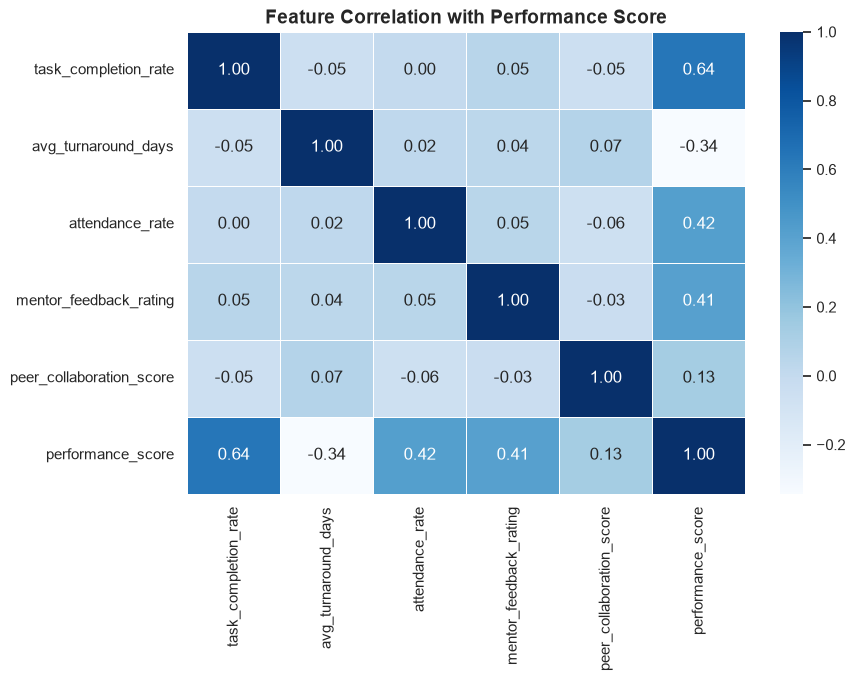

In [3]:
# Calculate correlation matrix focusing on numeric features
corr_cols = [
    'task_completion_rate',
    'avg_turnaround_days',
    'attendance_rate',
    'mentor_feedback_rating',
    'peer_collaboration_score',
    'performance_score'
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr_matrix, annot=True, cmap="Blues", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation with Performance Score", fontsize=14, fontweight="bold")
plt.show()

Step 4: Distribution of the Target Variable (performance_score)

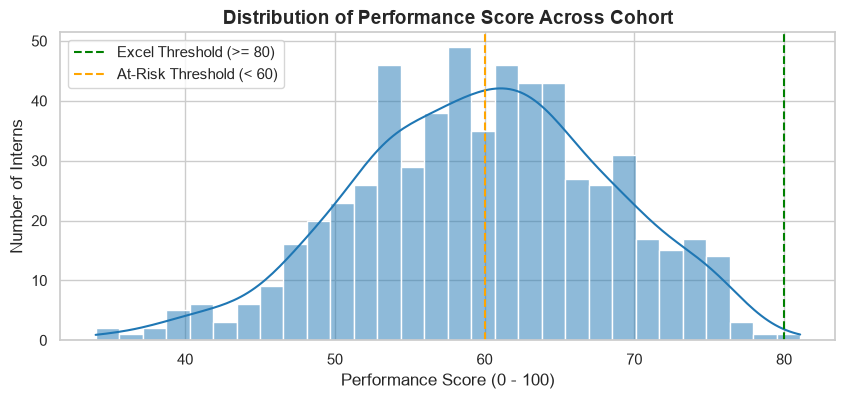

In [4]:
plt.figure(figsize=(10, 4))

sns.histplot(df['performance_score'], kde=True, bins=30, color="#1f77b4")
plt.axvline(80, color='green', linestyle='--', label='Excel Threshold (>= 80)')
plt.axvline(60, color='orange', linestyle='--', label='At-Risk Threshold (< 60)')

plt.title("Distribution of Performance Score Across Cohort", fontsize=14, fontweight="bold")
plt.xlabel("Performance Score (0 - 100)")
plt.ylabel("Number of Interns")
plt.legend()
plt.show()

Step 5: Feature-Target Splitting & Train/Test Split

In [5]:
features = [
    'task_completion_rate',
    'avg_turnaround_days',
    'attendance_rate',
    'mentor_feedback_rating',
    'peer_collaboration_score'
]
target = 'performance_score'

X = df[features]
y = df[target]

# 80% train, 20% test split with fixed seed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set : {X_test.shape[0]} samples")

Training set: 480 samples
Testing set : 120 samples


Step 6: Train Random Forest Regressor

In [6]:
# Initialize and fit Random Forest
rf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=7,
    min_samples_split=4,
    random_state=42
)
rf_model.fit(X_train, y_train)

# Predict on test data
rf_preds = rf_model.predict(X_test)

# Metrics calculation
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("=== Random Forest Regressor Evaluation ===")
print(f"MAE  : {rf_mae:.4f}")
print(f"RMSE : {rf_rmse:.4f}")
print(f"R²   : {rf_r2:.4f}")

=== Random Forest Regressor Evaluation ===
MAE  : 3.4856
RMSE : 4.2529
R²   : 0.7439


Step 7: Train & Evaluate XGBoost Regressor

In [7]:
# Initialize and fit XGBoost Regressor
xgb_model = xgb.XGBRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=42
)
xgb_model.fit(X_train, y_train)

# Predict on test data
xgb_preds = xgb_model.predict(X_test)

# Metrics calculation
xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_r2 = r2_score(y_test, xgb_preds)

print("=== XGBoost Regressor Evaluation ===")
print(f"MAE  : {xgb_mae:.4f}")
print(f"RMSE : {xgb_rmse:.4f}")
print(f"R²   : {xgb_r2:.4f}")

=== XGBoost Regressor Evaluation ===
MAE  : 3.0567
RMSE : 3.7954
R²   : 0.7960


Step 8: Head-to-Head Comparison Table

In [8]:
benchmark_df = pd.DataFrame({
    'Metric': ['MAE (Mean Absolute Error)', 'RMSE (Root Mean Squared Error)', 'R² Score'],
    'Random Forest': [rf_mae, rf_rmse, rf_r2],
    'XGBoost': [xgb_mae, xgb_rmse, xgb_r2]
})

benchmark_df['Winner'] = np.where(
    benchmark_df['Metric'] == 'R² Score',
    np.where(benchmark_df['XGBoost'] > benchmark_df['Random Forest'], 'XGBoost', 'Random Forest'),
    np.where(benchmark_df['XGBoost'] < benchmark_df['Random Forest'], 'XGBoost', 'Random Forest')
)

benchmark_df.round(4)

,Metric,Random Forest,XGBoost,Winner
0,MAE (Mean Absolute Error),3.4856,3.0567,XGBoost
1,RMSE (Root Mean Squared Error),4.2529,3.7954,XGBoost
2,R² Score,0.7439,0.7960,XGBoost


Step 9: Feature Importance & Interpretability

C:\Users\hp\AppData\Local\Temp\ipykernel_2712\3329693430.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='viridis')


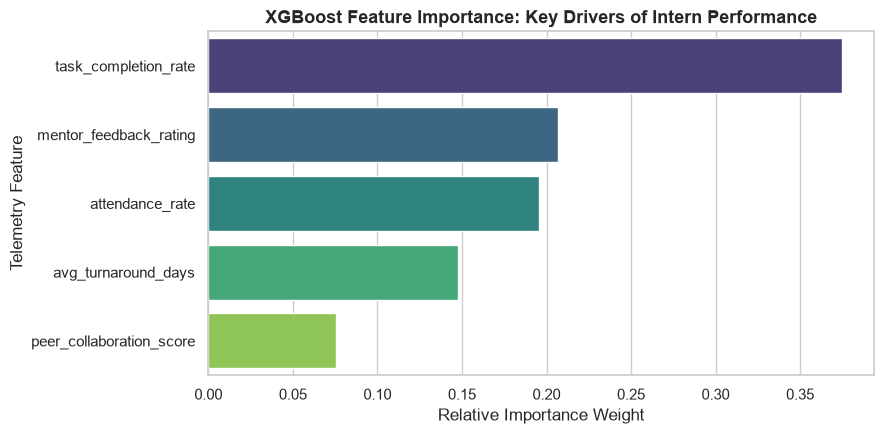

,Feature,Importance
0,task_completion_rate,0.374962
3,mentor_feedback_rating,0.206574
2,attendance_rate,0.195676
1,avg_turnaround_days,0.147485
4,peer_collaboration_score,0.075302


In [9]:
# Extract and visualize feature importance from XGBoost
importance = xgb_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(9, 4.5))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='viridis')
plt.title("XGBoost Feature Importance: Key Drivers of Intern Performance", fontsize=13, fontweight='bold')
plt.xlabel("Relative Importance Weight")
plt.ylabel("Telemetry Feature")
plt.tight_layout()
plt.show()

feature_importance_df

Step 10: Triage Risk Stratification (Excel vs. Struggle)

In [10]:
# Build test results table with classification categories
results_df = X_test.copy()
results_df['Actual_Score'] = y_test.values
results_df['Predicted_Score'] = np.round(xgb_preds, 2)

def assign_tier(score):
    if score >= 80.0:
        return 'Likely to Excel'
    elif score >= 60.0:
        return 'On Track'
    else:
        return 'Likely to Struggle (At Risk)'

results_df['Triage_Status'] = results_df['Predicted_Score'].apply(assign_tier)

print("--- Distribution of Predicted Intern Status ---")
print(results_df['Triage_Status'].value_counts())

print("\n--- Sample Test Predictions with Triage Tiers ---")
results_df[['Actual_Score', 'Predicted_Score', 'Triage_Status']].head(10)

--- Distribution of Predicted Intern Status ---
Triage_Status
On Track                        67
Likely to Struggle (At Risk)    53
Name: count, dtype: int64

--- Sample Test Predictions with Triage Tiers ---


,Actual_Score,Predicted_Score,Triage_Status
110,75.95,76.769997,On Track
419,68.73,68.739998,On Track
565,48.40,52.630001,Likely to Struggle (At Risk)
77,47.04,51.570000,Likely to Struggle (At Risk)
181,55.10,54.310001,Likely to Struggle (At Risk)
284,61.04,62.680000,On Track
10,57.99,56.160000,Likely to Struggle (At Risk)
469,57.67,63.610001,On Track
78,65.74,64.110001,On Track
349,50.23,53.290001,Likely to Struggle (At Risk)


Step 11: Serialize the Model Artifacts

In [ ]:
# Create models directory if not present
os.makedirs("../models", exist_ok=True)
model_filepath = os.path.join("..", "models", "best_model.pkl")

# Package model and metadata into an artifact dictionary
artifacts = {
    'model': xgb_model,
    'model_name': 'XGBoost Regressor',
    'features': features,
    'metrics': {
        'mae': xgb_mae,
        'rmse': xgb_rmse,
        'r2': xgb_r2
    }
}

joblib.dump(artifacts, model_filepath)
print(f"[OK] Best model successfully serialized to: {model_filepath}")

[OK] Best model successfully serialized to: ..\models\best_model.pkl
